<a href="https://colab.research.google.com/github/ThomasBizeul0/Higgs-TeamB/blob/Thomas/Copie_de_Copie_de_StartingKit_Black_Swan_HiggsML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# Starting Kit - Black Swan HiggsML Course
***

In [ ]:
COLAB = "google.colab" in str(get_ipython())

In [ ]:
if COLAB:
    ! git clone --depth 1 https://github.com/blackSwanCS/Higgs_collaborations.git

    ! git status
    %cd Higgs_collaborations

Cloning into 'Higgs_collaborations'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 1), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.17 MiB | 11.21 MiB/s, done.
Resolving deltas: 100% (1/1), done.
fatal: not a git repository (or any of the parent directories): .git
/content/Higgs_collaborations


In [ ]:
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 5.4 MB/s eta 0:00:00


### Imports

In [ ]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")

### Directories

In [ ]:
root_dir = os.getcwd()
print("Root directory is", root_dir)
submission_dir = os.path.join(root_dir, "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Root directory is /content/Higgs_collaborations


## Import Submission Model
We import a class named `Model` from the submission file (`model.py`). This `Model` class has the following methods:
- `init`: receives train set and systematics class as input
- `fit`: can be used for training
- `predict`: receives one test set and outputs a dictionary with the following keys
    - `mu_hat` : predicted mu $\hat{\mu}$
    - `delta_mu_hat`: $\Delta{\hat{\mu}}$ bound for $\mu$
    - `p16`: 16th percentile
    - `p84`: 84th percentile

In this example code, the `Model` class implements a basic model with 2 different model trained to predict the class label.

* 1 XGBoost BDT ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/boosted_decision_tree.py) )
* 2 Tebsorflow NN  ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/neural_network.py) )

The feature engineering is in where you can include derived quantities and decide which feature should be needed. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/feature_engineering.py) )

the statistical analysis part is where yoiu write the mu finding calculation using the output of the classifier. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/statistical_analysis.py) )

If running in Collab, click the folder icon in the left sidebar to open the file browser.


In [ ]:
path.append(submission_dir)
from model import Model

## Data
### Available data sets
1. blackSwan_data
2. sample_data
3. neurips2024_data

In [ ]:
from HiggsML.datasets import download_dataset

data = download_dataset(
    "blackSwan_data"
)  # change to "blackSwan_data" for the actual data

### ⚠️ Note:
The data used here is a small subset of the full data is for demonstration only to get a view of what the data looks like.

In [ ]:
# load train set
data.load_train_set()
data_set = data.get_train_set()

***
## Visualize the Data Set
***

In [ ]:
from tabulate import tabulate

target = data_set["labels"]
weights = data_set["weights"]
detailed_label = data_set["detailed_labels"]
keys = np.unique(detailed_label)


weight_keys = {}
average_weights = {}
for key in keys:
    weight_keys[key] = weights[detailed_label == key]

table_data = []
for key in keys:
    table_data.append(
        [
            key,
            np.sum(weight_keys[key]),
            len(weight_keys[key]),
            np.mean(weight_keys[key]),
        ]
    )

table_data.append(
    [
        "Total Signal",
        np.sum(weights[target == 1]),
        len(weights[target == 1]),
        np.mean(weights[target == 1]),
    ]
)
table_data.append(
    [
        "Total Background",
        np.sum(weights[target == 0]),
        len(weights[target == 0]),
        np.mean(weights[target == 0]),
    ]
)


print("[*] --- Detailed Label Summary")
print(
    tabulate(
        table_data,
        headers=[
            "Detailed Label",
            "Total Weight",
            "Number of events",
            "Average Weight",
        ],
        tablefmt="grid",
    )
)

[*] --- Detailed Label Summary
+------------------+----------------+--------------------+------------------+
| Detailed Label   |   Total Weight |   Number of events |   Average Weight |
+==================+================+====================+==================+
| diboson          |        382.109 |               3406 |       0.112187   |
+------------------+----------------+--------------------+------------------+
| htautau          |        675.897 |             462981 |       0.00145988 |
+------------------+----------------+--------------------+------------------+
| ttbar            |       4404.72  |              39293 |       0.112099   |
+------------------+----------------+--------------------+------------------+
| ztautau          |     100256     |             894320 |       0.112103   |
+------------------+----------------+--------------------+------------------+
| Total Signal     |        675.897 |             462981 |       0.00145988 |
+------------------+-------------

In [ ]:
print("\n[*] --- Examples of all features\n")
display(data_set.head())


[*] --- Examples of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
0,37.472000,0.676,-1.520,46.752998,0.623,1.500,-25.000000,-25.000,-25.000,-25.000,...,30.256184,-25.000,-25.000000,-25.000000,3.020465,30.256184,84.224998,0.801489,1.365776,-25.000000
1,26.006001,-0.087,-1.412,60.009998,-0.290,-0.099,134.770996,0.350,2.894,49.673,...,124.359779,2.009,232.705902,-0.580650,1.328600,9.316307,270.459991,0.433361,1.413247,0.726747
2,20.622999,-0.922,-0.436,41.917999,-1.356,2.524,-25.000000,-25.000,-25.000,-25.000,...,10.601603,-25.000,-25.000000,-25.000000,2.991648,10.601603,62.541000,0.491984,1.315526,-25.000000
3,48.394001,0.202,0.816,27.916000,-0.552,-2.387,-25.000000,-25.000,-25.000,-25.000,...,10.455322,-25.000,-25.000000,-25.000000,3.171129,10.455322,76.309998,1.733558,-1.409702,-25.000000
4,39.840000,-0.005,1.487,30.997000,1.747,2.681,73.082001,3.369,-1.286,31.274,...,92.074677,3.370,254.889191,-0.003369,2.120175,6.207835,175.192993,1.285286,1.037429,0.366135


In [ ]:
print("\n[*] --- Description of all features\n")
display(data_set.describe())


[*] --- Description of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
count,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,...,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06
mean,3.396482e+01,-1.664071e-03,3.532688e-04,4.310186e+01,-1.059442e-03,-7.431224e-04,2.039557e+01,-1.315356e+01,-1.315217e+01,-8.396195e+00,...,4.182135e+01,-1.887505e+01,5.100177e+01,-1.941999e+01,2.738726e+00,1.806350e+01,1.273698e+02,8.796806e-01,2.691063e-01,-1.930729e+01
std,1.805632e+01,1.223061e+00,1.812455e+00,2.133130e+01,1.245722e+00,1.813313e+00,6.295906e+01,1.259517e+01,1.258585e+01,3.418907e+01,...,5.430045e+01,1.150126e+01,2.375393e+02,1.052948e+01,6.101729e-01,1.600541e+01,1.093643e+02,5.091473e-01,1.215709e+00,1.053709e+01
min,2.000000e+01,-2.500000e+00,-3.142000e+00,2.287700e+01,-2.690000e+00,-3.142000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.173875e-02,-2.500000e+01,-2.500000e+01,-2.500000e+01,5.641427e-01,1.173875e-02,4.304400e+01,3.400616e-02,-1.414214e+00,-2.500000e+01
25%,2.395100e+01,-9.520000e-01,-1.568000e+00,3.077000e+01,-9.770000e-01,-1.572000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.094507e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.509546e+00,8.491425e+00,6.449300e+01,5.891082e-01,-1.332358e+00,-2.500000e+01
50%,2.901600e+01,-1.000000e-03,1.000000e-03,3.816800e+01,-1.000000e-03,3.000000e-03,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,2.156595e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.957897e+00,1.439308e+01,8.531300e+01,7.759828e-01,9.866624e-01,-2.500000e+01
75%,3.716600e+01,9.500000e-01,1.572000e+00,4.813200e+01,9.730000e-01,1.570000e+00,4.706200e+01,-1.560000e-01,-1.780000e-01,-2.500000e+01,...,4.885020e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,3.127119e+00,2.271586e+01,1.433570e+02,1.024202e+00,1.385667e+00,-2.500000e+01
max,1.101770e+03,2.500000e+00,3.142000e+00,8.452980e+02,2.680000e+00,3.142000e+00,1.203860e+03,4.991000e+00,3.142000e+00,1.001000e+03,...,1.175087e+03,9.666000e+00,6.555388e+03,2.229731e+01,5.804204e+00,7.199706e+02,2.497039e+03,2.160489e+01,1.414214e+00,1.000000e+00


[*] --- PRI_lep_phi histogram
[*] --- PRI_met histogram
[*] --- DER_mass_vis histogram
[*] --- DER_deltaeta_jet_jet histogram


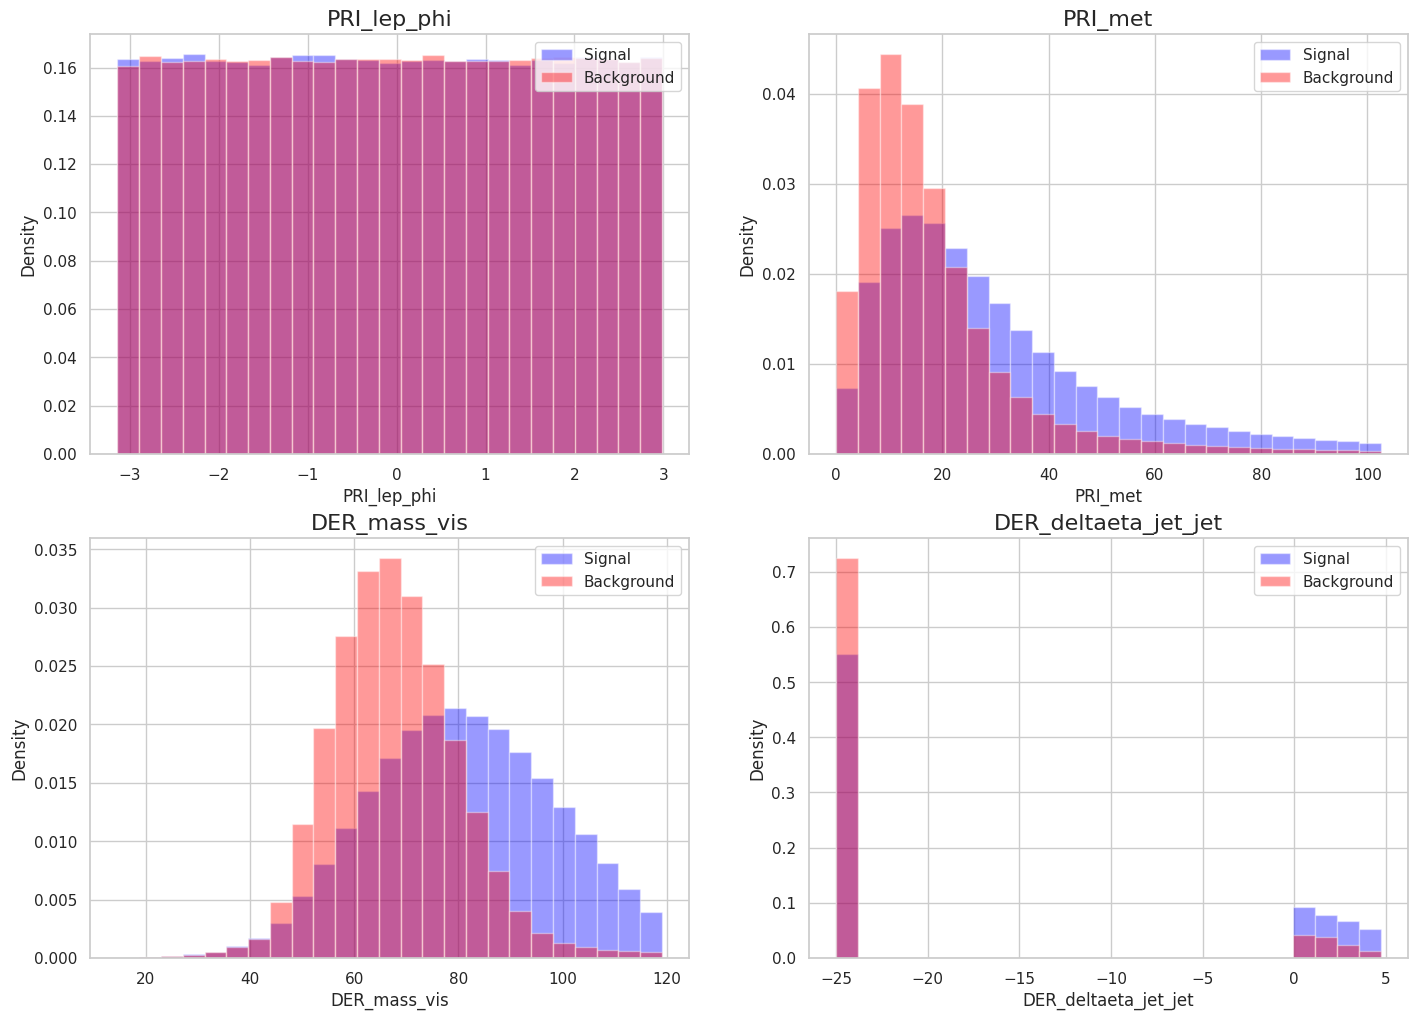

In [ ]:
from utils import histogram_dataset

# this function is defined in utils.py in the sample_code_submission directory. feel free to modify it as needed

histogram_dataset(
    data_set,
    target,
    weights,
    columns=["PRI_lep_phi", "PRI_met", "DER_mass_vis", "DER_deltaeta_jet_jet"],
)

Signal feature  correlation matrix


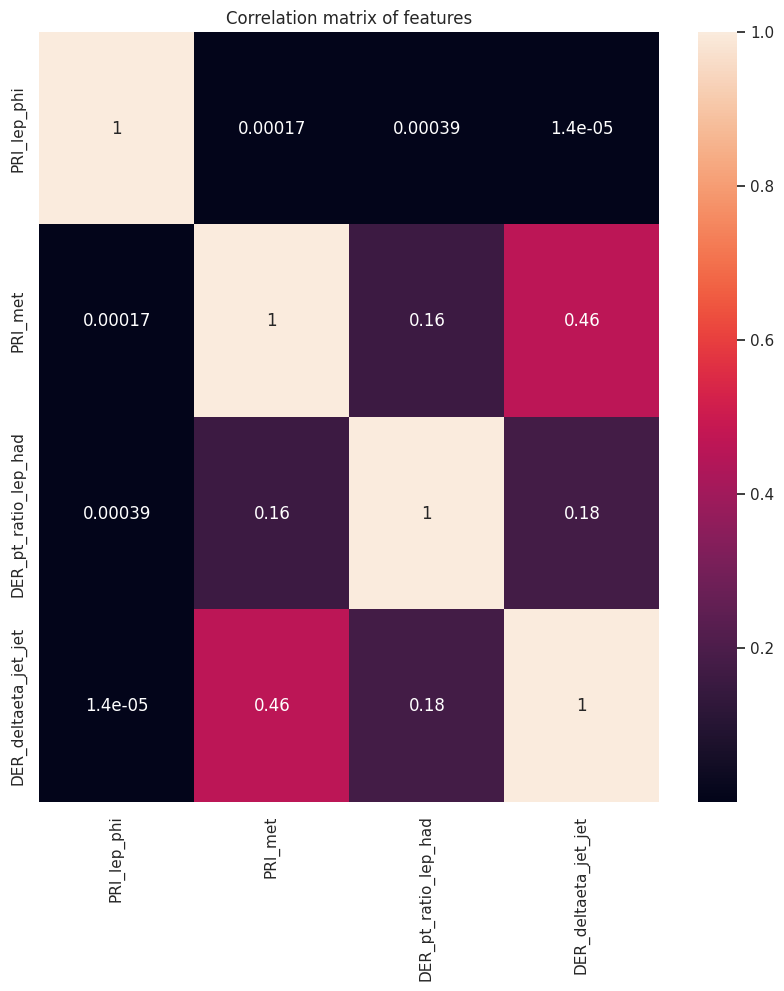

Background feature  correlation matrix


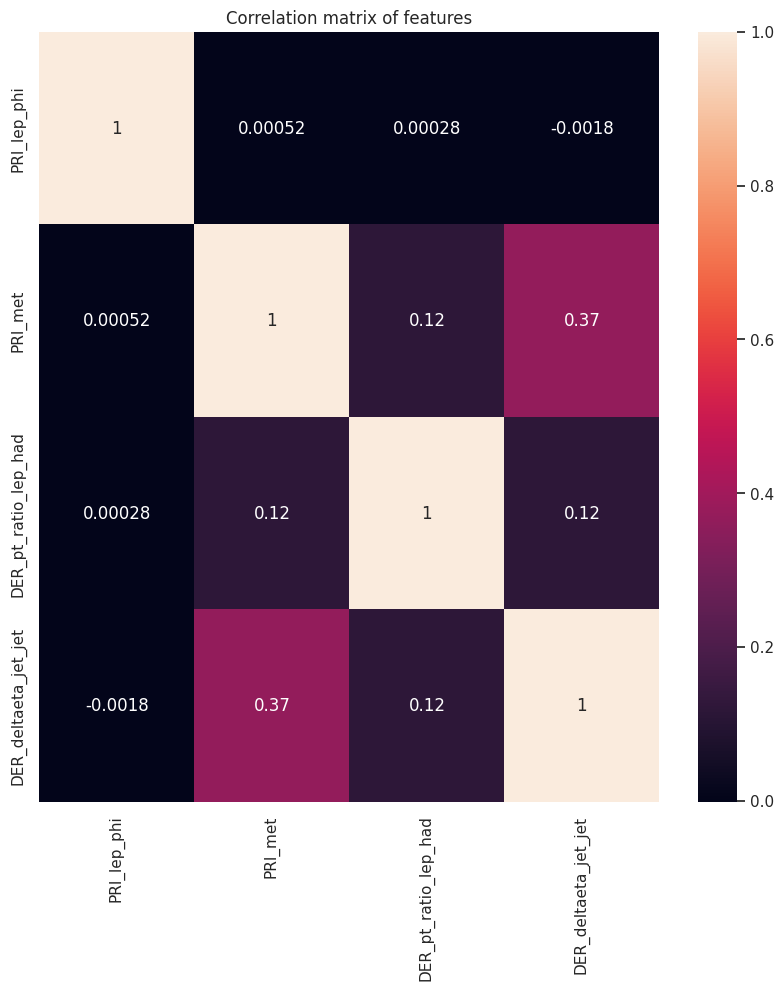

In [ ]:
import seaborn as sns

sns.set_theme(rc={"figure.figsize": (10, 10)}, style="whitegrid")

caption = ["Signal feature", "Background feature"]

for i in range(2):

    dfplot = pd.DataFrame(
        data_set,
        columns=[
            "PRI_lep_phi",
            "PRI_met",
            "DER_pt_ratio_lep_had",
            "DER_deltaeta_jet_jet",
        ],
    )

    print(caption[i], " correlation matrix")
    corrMatrix = dfplot[target == i].corr()
    sns.heatmap(corrMatrix, annot=True)
    plt.title("Correlation matrix of features")
    plt.show()

del dfplot

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


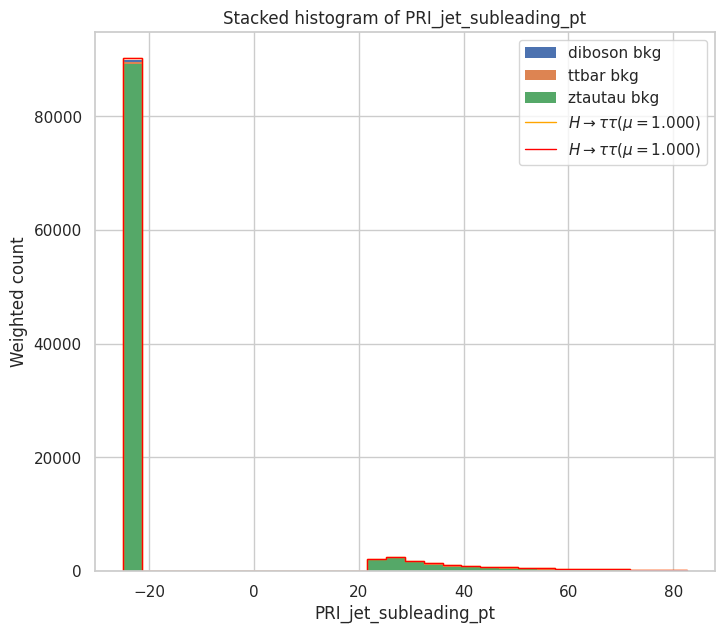

In [ ]:
from HiggsML.visualization import stacked_histogram

stacked_histogram(data_set, target, weights, detailed_label, "PRI_jet_subleading_pt")

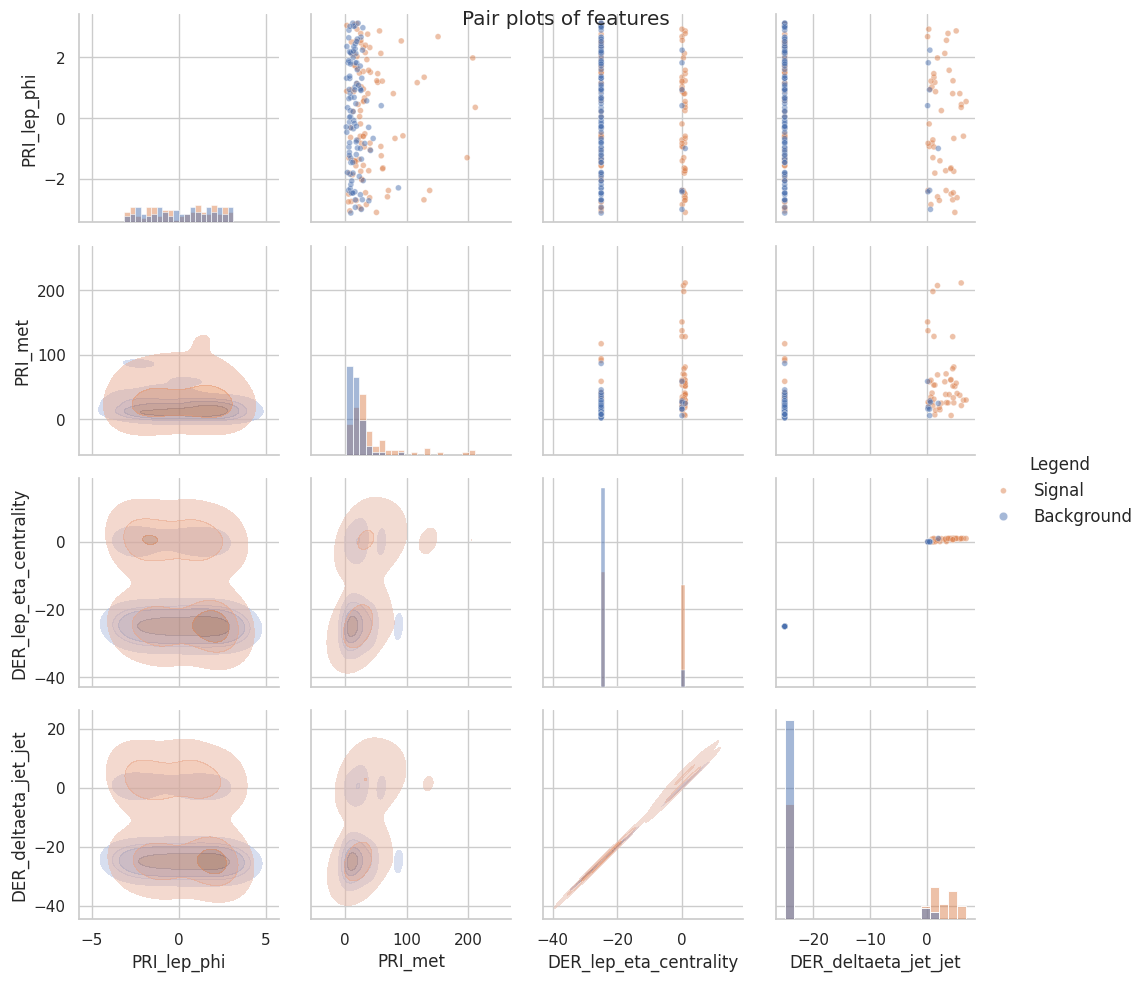

In [ ]:
from HiggsML.visualization import pair_plots

# Show data summary
pair_plots(
    data_set,
    target,
    sample_size=100,
    columns=[
        "PRI_lep_phi",
        "PRI_met",
        "DER_lep_eta_centrality",
        "DER_deltaeta_jet_jet",
    ],
)

### Ingestion



In [ ]:
from HiggsML.ingestion import Ingestion

ingestion = Ingestion(data)

In [ ]:
# initialize submission
ingestion.init_submission(Model, "BDT")

Training Data:  (5000, 28)
Training Labels:  (5000,)
Training Weights:  (5000,)
sum_signal_weights:  638.0219088856879
sum_bkg_weights:  105080.97809111432

Valid Data:  (5000, 28)
Valid Labels:  (5000,)
Valid Weights:  (5000,)
sum_signal_weights:  680.4398003050059
sum_bkg_weights:  105038.56019969496

Holdout Data:  (5000, 28)
Holdout Labels:  (5000,)
Holdout Weights:  (5000,)
sum_signal_weights:  683.5037038295454
sum_bkg_weights:  105035.49629617043
 
 
Training Data:  (5000, 28)
DEBUG: model_type = 'BDT'
 Model is BDT


score shape before threshold (4599,)
score shape after threshold (4599,)
saved_info {'beta': np.float64(12415.43300258616), 'gamma': np.float64(445.05501979213403), 'tes_fit': <function tes_fitter.<locals>.fit_function at 0x7bb78577dee0>, 'jes_fit': <function jes_fitter.<locals>.fit_function at 0x7bb78577df80>}
Train Results: 
	 mu_hat  :  -26.080010386953713
	 del_mu_stat  :  0.25480915098671303
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.25480915098671303
Holdout Results: 
	 mu_hat  :  1.0000000000000058
	 del_mu_stat  :  0.25480915098671303
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.25480915098671303
Valid Results: 
	 mu_hat  :  2.571251360116664
	 del_mu_stat  :  0.25480915098671303
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.25480915098671303
[*] --- score histogram


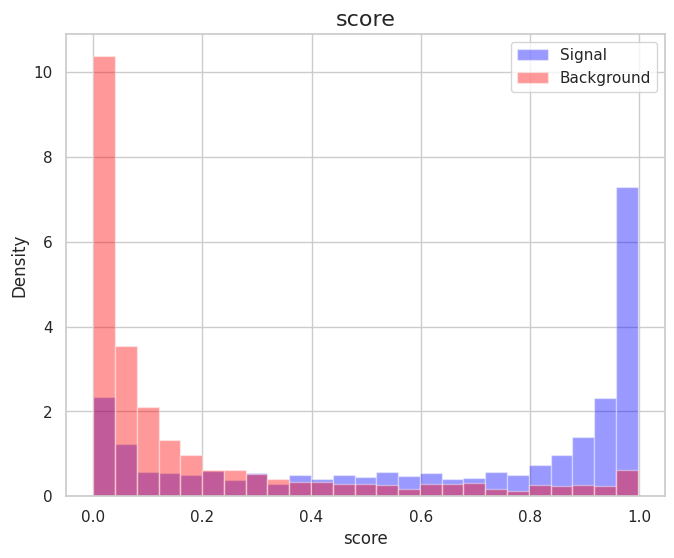

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


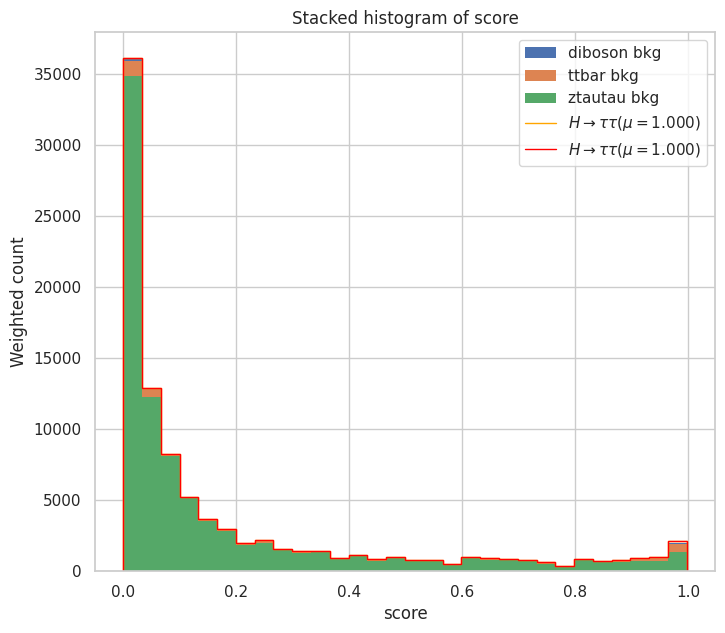

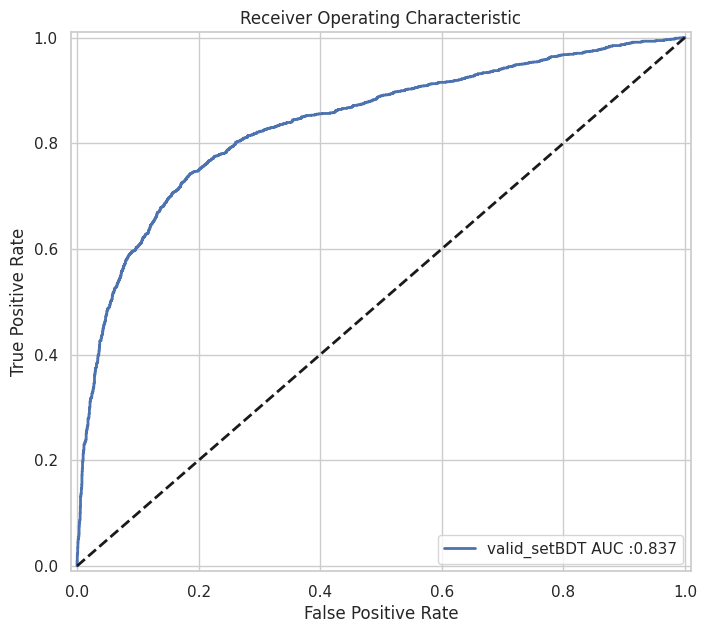

In [ ]:
# fit submission
ingestion.fit_submission()

In [ ]:
# load test set
data.load_test_set()

### Test Settings
The Test setting sets the test conditions in ingestion.
This includes what systematics you want and how many psuedo experiments you want.

In [ ]:
test_settings = {
    "systematics": {  # Systematics to use
        "tes": False,  # tau energy scale
        "jes": False,  # jet energy scale
        "soft_met": False,  # soft term in MET
        "ttbar_scale": False,  # W boson scale factor
        "diboson_scale": False,  # Diboson scale factor
        "bkg_scale": False,  # Background scale factor
    },
    "num_pseudo_experiments": 500,  # Number of pseudo-experiments to run per set
    "num_of_sets": 1,  # Number of sets of pseudo-experiments to run
}

RANDOM_SEED = 42

random_state = np.random.RandomState(RANDOM_SEED)
test_settings["ground_truth_mus"] = (
    random_state.uniform(0.1, 3, test_settings["num_of_sets"])
).tolist()
test_settings["jes"] = 1.03
random_settings_file = os.path.join(output_dir, "test_settings.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)

In [ ]:
# predict submission
ingestion.predict_submission(test_settings)

Test Results:  {'mu_hat': np.float64(2.4301871663395533), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
Test Results:  {'mu_hat': np.float64(2.2616686761200087), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
Test Results:  {'mu_hat': np.float64(1.94036008810141), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
Test Results:  {'mu_hat': np.float64(2.0909032726975365), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
Test Results:  {'mu_hat': np.float64(2.8099154976342606), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
Test Results:  {'mu_hat': np.float64(2.29312546096099), 'del_mu_stat': np.float64(

In [ ]:
ingestion.process_results_dict()

In [ ]:
# save result
ingestion.save_result(output_dir)

## Score
1. Compute Scores
2. Visualize Scores


In [ ]:
from HiggsML.score import Scoring

In [ ]:
# Initialize Score
score = Scoring()

In [ ]:
print(output_dir)
score.load_ingestion_results(prediction_dir=output_dir, score_dir=output_dir)

/content/Higgs_collaborations/sample_result_submission


[✔]


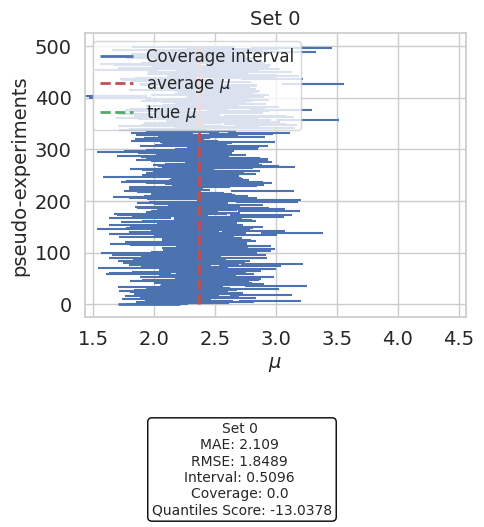

In [ ]:
# Compute Score
score.compute_scores(test_settings)

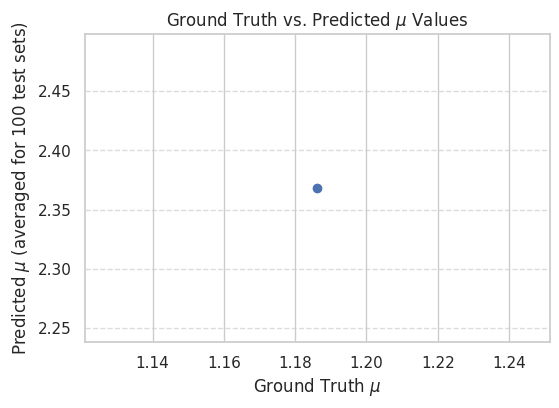

In [ ]:
from HiggsML.visualization import visualize_scatter

# Visualize scatter plot of ground truth mu and predicted mu
visualize_scatter(
    ingestion_result_dict=ingestion.results_dict,
    ground_truth_mus=test_settings["ground_truth_mus"],
)

In [ ]:
!python -m HiggsML.score --prediction $output_dir --output $output_dir

############################################
### Scoring Program
############################################

/content/Higgs_collaborations/sample_result_submission/test_settings.json
2026-06-02 15:02:45,634 - HiggsML.score        - INFO     - Reading ingestion duration from /content/Higgs_collaborations/sample_result_submission/ingestion_duration.json
2026-06-02 15:02:45,634 - HiggsML.score        - WARNING  - File /content/Higgs_collaborations/sample_result_submission/ingestion_duration.json not found. Setting ingestion duration to 0.
/content/Higgs_collaborations/sample_result_submission
2026-06-02 15:02:45,635 - HiggsML.score        - INFO     - Read ingestion results from /content/Higgs_collaborations/sample_result_submission
2026-06-02 15:02:45,635 - HiggsML.score        - INFO     - Computing scores
[✔]
rmse     1.8489
mae     2.109
interval     0.5096
coverage     0.0
quantiles_score     -13.0378
ingestion_duration     0
2026-06-02 15:02:46,602 - HiggsML.score        - INFO   

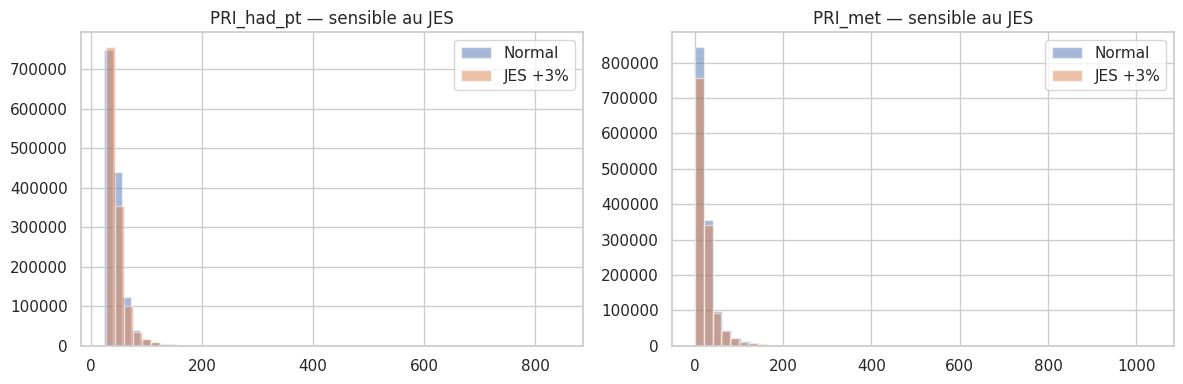

In [ ]:
from HiggsML.systematics import systematics
from HiggsML.datasets import download_dataset

"""Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='str')"""

# Charger les données normales
data_normal = download_dataset("blackSwan_data")  # votre dataset de base

data_normal.load_train_set()
data_train = data_normal.get_train_set()

# Appliquer une variation TES de 3%
data_with_JES = systematics(data_train, jes=0.97)  # -3% sur l'énergie des taus

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(data_train["PRI_had_pt"], bins=50, alpha=0.5, label="Normal")
plt.hist(data_with_JES["PRI_had_pt"], bins=50, alpha=0.5, label="JES +3%")
plt.legend()
plt.title("PRI_had_pt — sensible au JES")

plt.subplot(1, 2, 2)
plt.hist(data_train["PRI_met"], bins=50, alpha=0.5, label="Normal")
plt.hist(data_with_JES["PRI_met"], bins=50, alpha=0.5, label="JES +3%")
plt.legend()
plt.title("PRI_met — sensible au JES")

plt.tight_layout()
plt.show()

In [ ]:
from HiggsML.systematics import systematics
from HiggsML.datasets import download_dataset

"""Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='str')"""

# Charger les données normales
data_normal = download_dataset("blackSwan_data")  # votre dataset de base

data_normal.load_train_set()
data_train = data_normal.get_train_set()

Text(0.5, 1.0, 'PRI_had_pt — sensible au JES')

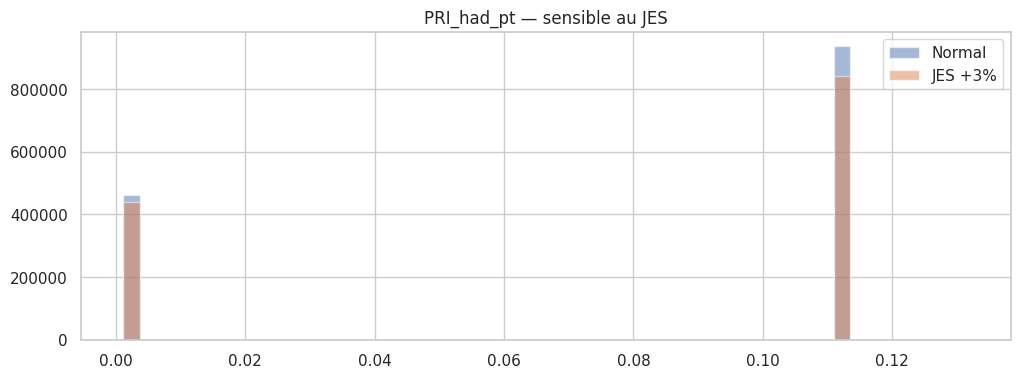

In [ ]:
from HiggsML.systematics import systematics
from HiggsML.datasets import download_dataset

"""Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='str')"""

# Charger les données normales
data_normal = download_dataset("blackSwan_data")  # votre dataset de base

data_normal.load_train_set()
data_train = data_normal.get_train_set()

# Appliquer une variation TES de 3%
data_with_JES = systematics(data_train, jes=0.97)  # -3% sur l'énergie des taus

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))


plt.hist(data_train["weights"], bins=50, alpha=0.5, label="Normal")
plt.hist(data_with_JES["weights"], bins=50, alpha=0.5, label="JES +3%")
plt.legend()
plt.title("PRI_had_pt — sensible au JES")

In [ ]:
# To calculate the score, we need to import the compute_mu function
from statistical_analysis import compute_mu

# Get the feature columns by excluding non-feature columns
non_feature_cols = ["weights", "labels", "detailed_labels"]
feature_cols = [col for col in data_train.columns if col not in non_feature_cols]

print("-- Scores for Normal Data (data_train) ---")
# Prepare input for prediction for data_train
predict_input_train = {
    "data": data_train[feature_cols],
    "weights": data_train["weights"],
}
# Get predictions (scores) from the model. This dictionary already contains mu_hat etc.
mu_results_train = ingestion.model.predict(predict_input_train)
print(mu_results_train)

print("\n--- Scores for JES-varied Data (data_with_JES, JES=0.97) ---")
# Prepare input for prediction for data_with_JES
predict_input_jes = {
    "data": data_with_JES[feature_cols],
    "weights": data_with_JES["weights"],
}
# Get predictions (scores) from the model. This dictionary already contains mu_hat etc.
mu_results_jes = ingestion.model.predict(predict_input_jes)
print(mu_results_jes)

-- Scores for Normal Data (data_train) ---
Test Results:  {'mu_hat': np.float64(4.451393978171525), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
{'mu_hat': np.float64(4.451393978171525), 'delta_mu_hat': np.float64(0.25480915098671303), 'p16': np.float64(4.196584827184812), 'p84': np.float64(4.706203129158237)}

--- Scores for JES-varied Data (data_with_JES, JES=0.97) ---
Test Results:  {'mu_hat': np.float64(1.042683155513173), 'del_mu_stat': np.float64(0.25480915098671303), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.25480915098671303)}
{'mu_hat': np.float64(1.042683155513173), 'delta_mu_hat': np.float64(0.25480915098671303), 'p16': np.float64(0.7878740045264601), 'p84': np.float64(1.297492306499886)}



--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


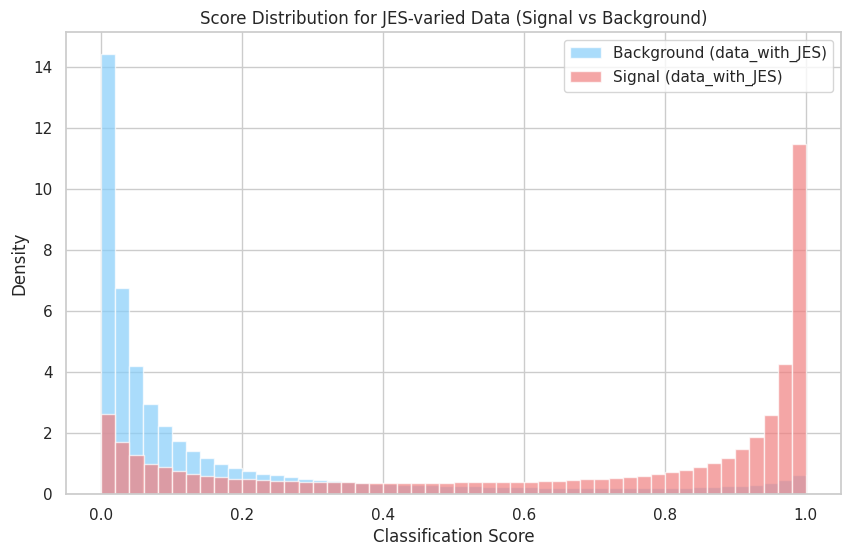


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


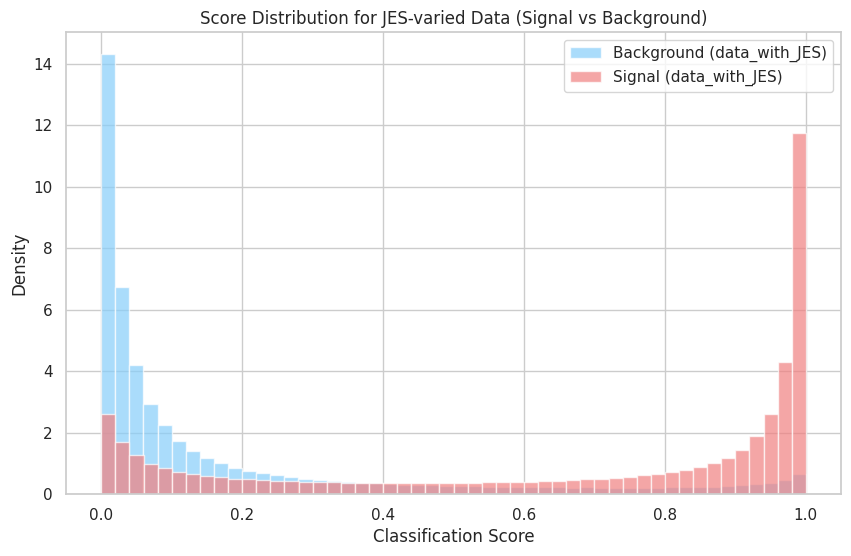


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


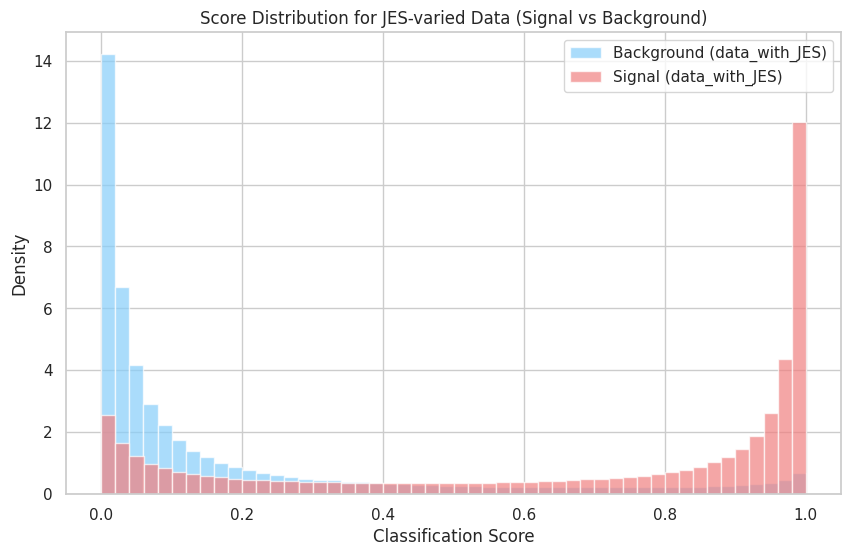


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


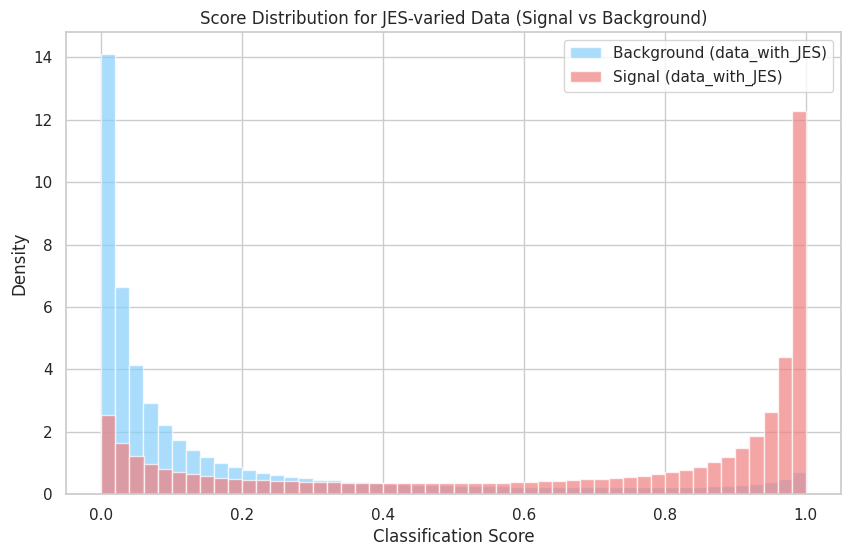


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


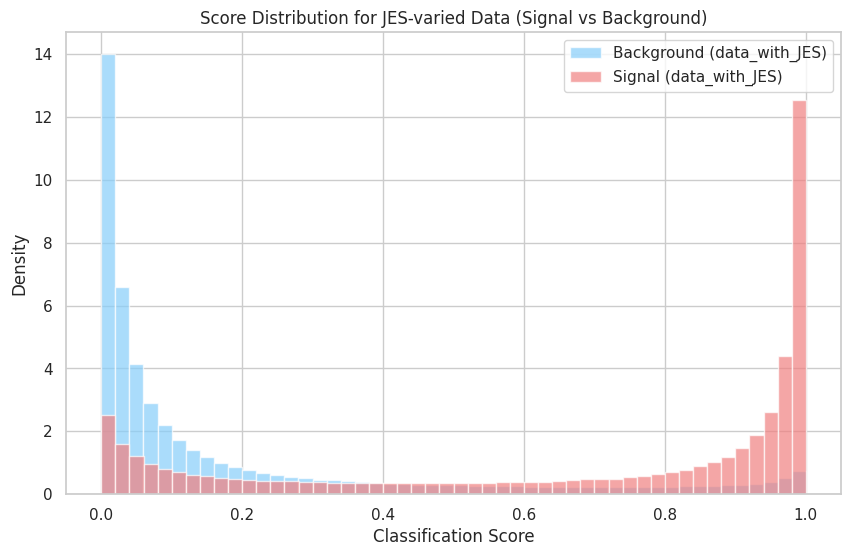

In [ ]:
L = np.linspace(0.97, 1.03, 5)
for jesval in L:
    data_with_JES = systematics(data_train, jes=jesval)  # variation de jes
    import matplotlib.pyplot as plt

    print("\n--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---")

    # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
    non_feature_cols = ["weights", "labels", "detailed_labels"]
    feature_cols = [col for col in data_with_JES.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
    raw_scores_jes = ingestion.model.model.predict(data_with_JES[feature_cols])

    signal_scores_jes = raw_scores_jes[data_with_JES["labels"] == 1]
    background_scores_jes = raw_scores_jes[data_with_JES["labels"] == 0]

    # Plot the distributions for data_with_JES
    plt.figure(figsize=(10, 6))
    plt.hist(
        background_scores_jes,
        bins=50,
        alpha=0.7,
        label="Background (data_with_JES)",
        color="lightskyblue",
        density=True,
    )
    plt.hist(
        signal_scores_jes,
        bins=50,
        alpha=0.7,
        label="Signal (data_with_JES)",
        color="lightcoral",
        density=True,
    )
    plt.title("Score Distribution for JES-varied Data (Signal vs Background)")
    plt.xlabel("Classification Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
data_with_JES = systematics(data_train, jes=1)  # variation de jes
import matplotlib.pyplot as plt

# Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
non_feature_cols = ["weights", "labels", "detailed_labels"]
feature_cols = [col for col in data_with_JES.columns if col not in non_feature_cols]

# Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
# Assuming predict returns probabilities/scores directly.
raw_scores_jes = ingestion.model.model.predict(data_with_JES[feature_cols])

signal_scores_jes = raw_scores_jes[data_with_JES["labels"] == 1]
background_scores_jes = raw_scores_jes[data_with_JES["labels"] == 0]

print(signal_scores_jes)

s = 0
b = 0
n = 0
for i in signal_scores_jes:
    if i > 0.5:
        s = s + 1
for i in background_scores_jes:
    if i > 0.5:
        b = b + 1
n = s + b
print(n, s, b)

liste = []

L = np.linspace(0.97, 1.03, 10)
for jesval in L:
    data_with_JES = systematics(data_train, jes=jesval)  # variation de jes
    import matplotlib.pyplot as plt

    # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
    non_feature_cols = ["weights", "labels", "detailed_labels"]
    feature_cols = [col for col in data_with_JES.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
    raw_scores_jes = ingestion.model.model.predict(data_with_JES[feature_cols])

    signal_scores_jes = raw_scores_jes[data_with_JES["labels"] == 1]
    background_scores_jes = raw_scores_jes[data_with_JES["labels"] == 0]

    print(signal_scores_jes)

    s = 0
    b = 0
    for i in signal_scores_jes:
        if i > 0.5:
            s = s + 1
    for i in background_scores_jes:
        if i > 0.5:
            b = b + 1
    mu = (n - b) / s
    print(mu, s, b)
    liste.append(mu)
    print(liste)

[0.38312593 0.34429875 0.99104226 ... 0.9919652  0.09157655 0.9939958 ]
413867 297957 115910
[0.38312593 0.34429875 0.99117166 ... 0.9919652  0.0744219  0.9939958 ]
1.030572827858949 293823 111061
[1.030572827858949]
[0.38312593 0.34429875 0.992523   ... 0.9919652  0.0744219  0.9939958 ]
1.0234334458256313 294835 112123
[1.030572827858949, 1.0234334458256313]
[0.38312593 0.34429875 0.99104226 ... 0.9919652  0.0744219  0.9939958 ]
1.0164007032253701 295780 113236
[1.030572827858949, 1.0234334458256313, 1.0164007032253701]
[0.38312593 0.34429875 0.99104226 ... 0.9919652  0.09157655 0.9939958 ]
1.0096982649645543 296651 114339
[1.030572827858949, 1.0234334458256313, 1.0164007032253701, 1.0096982649645543]
[0.38312593 0.34429875 0.99104226 ... 0.9919652  0.09157655 0.9939958 ]
1.003465977281208 297463 115373
[1.030572827858949, 1.0234334458256313, 1.0164007032253701, 1.0096982649645543, 1.003465977281208]
[0.38312593 0.34429875 0.99104226 ... 0.9919652  0.09157655 0.9939958 ]
0.99643133588

In [ ]:
import matplotlib.pyplot as plt

plt.plot(L, liste)
plt.show()